# Yellowbrick Plotting

This notebook demonstrates deckard's Yellowbrick integration using Yellowbrick-native datasets.

## Goals

1. Load Yellowbrick-native datasets through `DataConfig`.
2. Illustrate all supported `YellowbrickPlotConfig` plot types.
3. Explain and demonstrate `YellowbrickConfigList` (`plotlist`) behavior.
4. Show torch support with a small synthetic dataset and a `TinyNet` model.

## Optional Dependencies

This notebook uses Yellowbrick plotting and includes torch-based examples.

Recommended extras:

- `docs`
- `yellowbrick`
- `torch`

Install from repository root:

```bash
pip install -e '.[docs,yellowbrick,torch]'
```


In [1]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[docs,yellowbrick,torch]'

In [2]:
import importlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

import deckard.plugins.yellowbrick.plot as yellowbrick_plots_mod
from deckard.data import DataConfig
from deckard.experiment import ExperimentConfig
from deckard.file import FileConfig
from deckard.frameworks.pytorch.data import PytorchDataConfig
from deckard.frameworks.pytorch.model import PytorchModelConfig
from deckard.model import ModelConfig

importlib.reload(yellowbrick_plots_mod)

YellowbrickPlotConfig = yellowbrick_plots_mod.YellowbrickPlotConfig
YellowbrickConfigList = yellowbrick_plots_mod.YellowbrickConfigList
feature_viz_types = yellowbrick_plots_mod.feature_viz_types
target_viz_types = yellowbrick_plots_mod.target_viz_types
classifier_viz_types = yellowbrick_plots_mod.classifier_viz_types
regressor_viz_types = yellowbrick_plots_mod.regressor_viz_types
cluster_viz_types = yellowbrick_plots_mod.cluster_viz_types
model_selection_viz_types = yellowbrick_plots_mod.model_selection_viz_types

NOTEBOOK_ROOT = Path(".")
ARTIFACT_DIR = NOTEBOOK_ROOT / "build" / "yellowbrick"
PLOT_DIR = ARTIFACT_DIR / "plots"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
PLOT_DIR.mkdir(parents=True, exist_ok=True)

plt.rcParams["figure.figsize"] = (9, 6)
pd.set_option("display.max_columns", 50)

print(f"Artifact directory: {ARTIFACT_DIR}")
print(f"Torch version: {torch.__version__}")

/opt/hostedtoolcache/Python/3.10.20/x64/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Artifact directory: build/yellowbrick
Torch version: 2.12.0+cpu


## 2. Discover Yellowbrick-Native Datasets

deckard maps Yellowbrick dataset loaders into `DataConfig` names such as `yellowbrick_energy` and `yellowbrick_occupancy`.

In [3]:
yellowbrick_datasets_mod = importlib.import_module("yellowbrick.datasets")
yb_loader_names = sorted(
    name.replace("load_", "", 1)
    for name in dir(yellowbrick_datasets_mod)
    if name.startswith("load_") and callable(getattr(yellowbrick_datasets_mod, name))
)


def build_yb_data(dataset_name: str, classifier: bool):
    cfg = DataConfig(
        dataset_name=f"yellowbrick_{dataset_name}",
        train_size=0.8,
        test_size=0.2,
        random_state=42,
        classifier=classifier,
        stratify=False,
    )
    cfg()
    return cfg


def pick_dataset(task: str, preferred_names):
    candidates = list(dict.fromkeys(list(preferred_names) + yb_loader_names))
    for name in candidates:
        try:
            task_classifier = True if task == "classification" else False
            probe = build_yb_data(name, classifier=task_classifier)
            y = pd.Series(probe.y_train)
            nunique = int(y.nunique(dropna=False))
            is_numeric = pd.api.types.is_numeric_dtype(y)
            if task == "classification" and nunique >= 2 and nunique <= 30:
                return name, probe
            if task == "regression" and is_numeric and nunique > 30:
                reg_cfg = build_yb_data(name, classifier=False)
                return name, reg_cfg
            if task == "cluster" and probe.X_train.shape[1] >= 2:
                cluster_cfg = build_yb_data(name, classifier=False)
                return name, cluster_cfg
        except Exception:
            continue
    raise RuntimeError(f"Could not find a working Yellowbrick-native dataset for {task}")


classification_name, classification_data = pick_dataset(
    "classification",
    preferred_names=["occupancy", "mushroom", "spam", "credit"],
)
regression_name, regression_data = pick_dataset(
    "regression",
    preferred_names=["energy", "concrete"],
)
cluster_name, cluster_data = pick_dataset(
    "cluster",
    preferred_names=["occupancy", "mushroom", "credit"],
)

print("Available Yellowbrick loaders:", yb_loader_names)
print("Selected classification dataset:", classification_name, classification_data.X_train.shape)
print("Selected regression dataset:", regression_name, regression_data.X_train.shape)
print("Selected clustering dataset:", cluster_name, cluster_data.X_train.shape)

Available Yellowbrick loaders: ['bikeshare', 'concrete', 'credit', 'energy', 'game', 'hobbies', 'mushroom', 'nfl', 'occupancy', 'spam', 'walking']
Selected classification dataset: occupancy (16448, 5)
Selected regression dataset: energy (614, 8)
Selected clustering dataset: occupancy (16448, 5)


## 3. Build Experiments (Mostly sklearn)

Most examples in this notebook use sklearn estimators through `ModelConfig`, matching the primary Yellowbrick usage pattern.

In [4]:
classification_model = ModelConfig(
    model_type="sklearn.linear_model.LogisticRegression",
    classifier=True,
    model_params={"max_iter": 300},
)
regression_model = ModelConfig(
    model_type="sklearn.linear_model.Ridge",
    classifier=False,
    model_params={"alpha": 1.0},
)
cluster_model = ModelConfig(
    model_type="sklearn.cluster.KMeans",
    classifier=False,
    scorer=None, #TODO: Add default cluster-scoring
    model_params={"n_clusters": 3, "n_init": 10, "random_state": 42},
)

cls_experiment = ExperimentConfig(
    data=classification_data,
    model=classification_model,
    classifier=True,
    files=FileConfig(),
)

reg_experiment = ExperimentConfig(
    data=regression_data,
    model=regression_model,
    classifier=False,
    files=FileConfig(),
)

cluster_experiment = ExperimentConfig(
    data=cluster_data,
    model=cluster_model,
    classifier=False,
    files=FileConfig(),
)

_ = cls_experiment()
_ = reg_experiment()
_ = cluster_experiment()

print("Prepared classification, regression, and clustering experiments.")

Prepared classification, regression, and clustering experiments.


## 4. Plot Gallery: One Cell per Plot Type

Each of the supported `YellowbrickPlotConfig` plot types gets its own code cell below.

Explanations are based on the scikit-yb API index and visualizer docs:

- API index: https://www.scikit-yb.org/en/latest/api/index.html
- Feature visualizers: rank, projection, manifold structure
- Target visualizers: class distribution and target-feature relationship
- Model visualizers: classifier/regressor/clustering behavior and model-selection diagnostics

In [5]:
all_plot_types = (
    feature_viz_types
    + target_viz_types
    + classifier_viz_types
    + regressor_viz_types
    + cluster_viz_types
    + model_selection_viz_types
)

cls_feature_names = list(classification_data.X_train.columns)
cls_columns = cls_feature_names[:2] if len(cls_feature_names) >= 2 else "all"

plot_results = []


def render_plot(plot_type: str, explanation: str):
    """Render one Yellowbrick plot and append status rows."""
    if plot_type in regressor_viz_types:
        experiment = reg_experiment
    elif plot_type in cluster_viz_types:
        experiment = cluster_experiment
    else:
        experiment = cls_experiment

    params = {}
    if plot_type == "jointplot" and cls_columns != "all":
        params["columns"] = cls_columns
    if plot_type == "alpha_selection":
        params["alphas"] = np.logspace(-3, 3, 7).tolist()
    if plot_type in model_selection_viz_types:
        params["cv"] = 3
    if plot_type == "validation_curve":
        params["param_name"] = "C"
        params["param_range"] = [1e-3, 1e2, "log"]
        params["num"] = 5
    if plot_type == "learning_curve":
        params["param_range"] = [0.2, 1.0, "linear"]
        params["num"] = 5

    save_path = (PLOT_DIR / f"all_types_{plot_type}.png").as_posix()
    plot_cfg = YellowbrickPlotConfig(
        experiment=experiment,
        plot_type=plot_type,
        clustering=(plot_type in cluster_viz_types),
        features="all",
        classes="all",
        title=f"{plot_type.replace('_', ' ').title()} ({experiment.model.model_type})",
        save_path=save_path,
        plot_params=params,
    )

    try:
        _ = plot_cfg()
        status = "ok"
        error = ""
    except Exception as exc:
        status = "failed"
        error = str(exc)

    row = {
        "plot_type": plot_type,
        "status": status,
        "save_path": save_path,
        "error": error,
        "explanation": explanation,
    }
    plot_results.append(row)
    print(f"[{status}] {plot_type}: {explanation}")
    if error:
        print("error:", error)
    return pd.DataFrame([row])

## 5. Explain the PlotList Object (`YellowbrickConfigList`)

`YellowbrickConfigList` is a convenience orchestrator for rendering many Yellowbrick plots from one prepared experiment.

How it works:

- It prepares experiment state once (data/model outputs).
- It expands a list of plot types (or `"all"`) into child `YellowbrickPlotConfig` objects.
- It runs each plot config and writes outputs to a shared folder.

This is ideal when you want a diagnostics suite instead of one-off plots.

PlotList generated files:
 - build/yellowbrick/plots/plotlist_demo/class_balance.png
 - build/yellowbrick/plots/plotlist_demo/classification_report.png
 - build/yellowbrick/plots/plotlist_demo/precision_recall_curve.png
 - build/yellowbrick/plots/plotlist_demo/rank1d.png
 - build/yellowbrick/plots/plotlist_demo/roc_auc.png


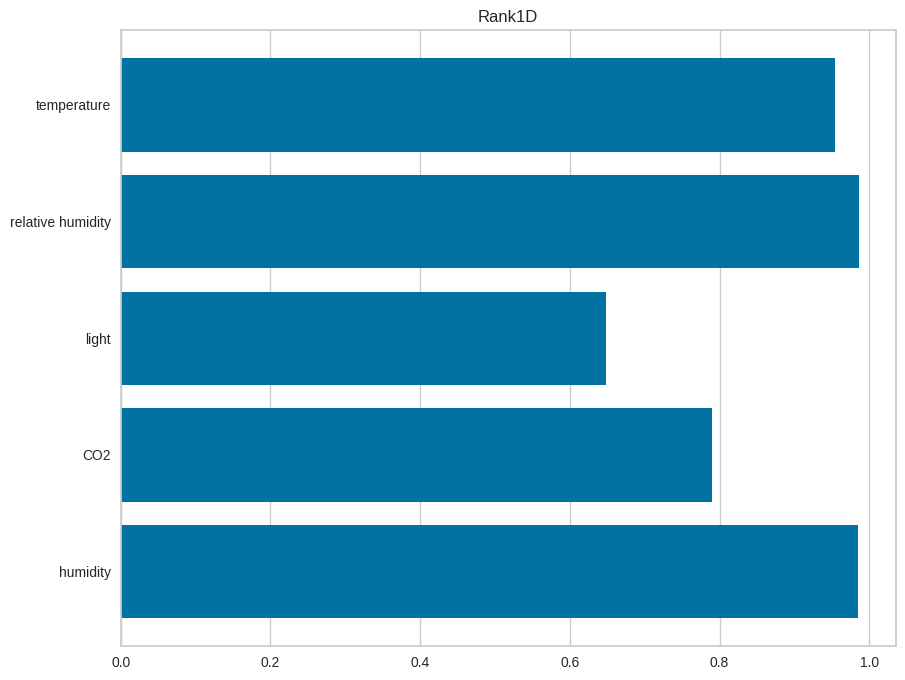

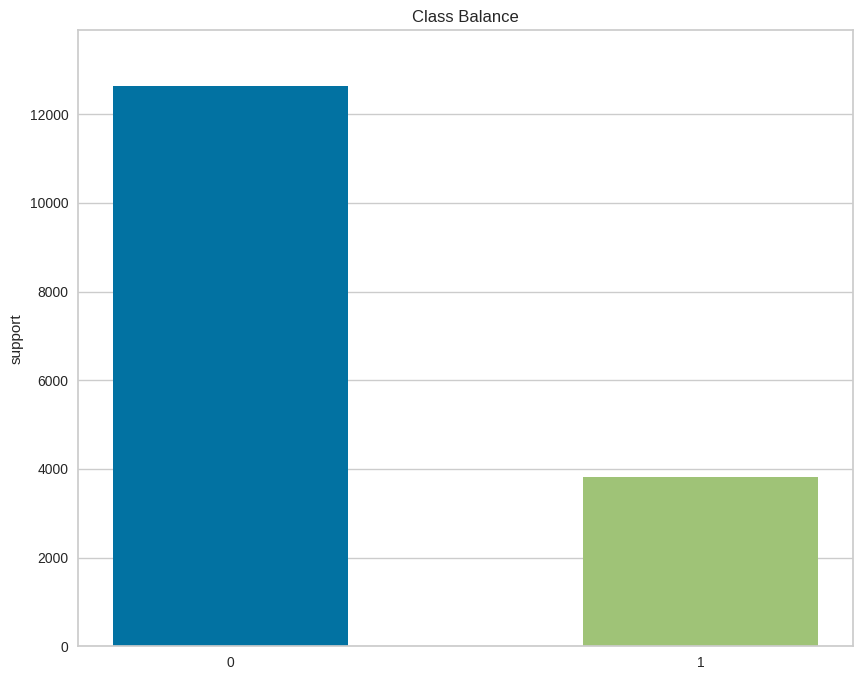

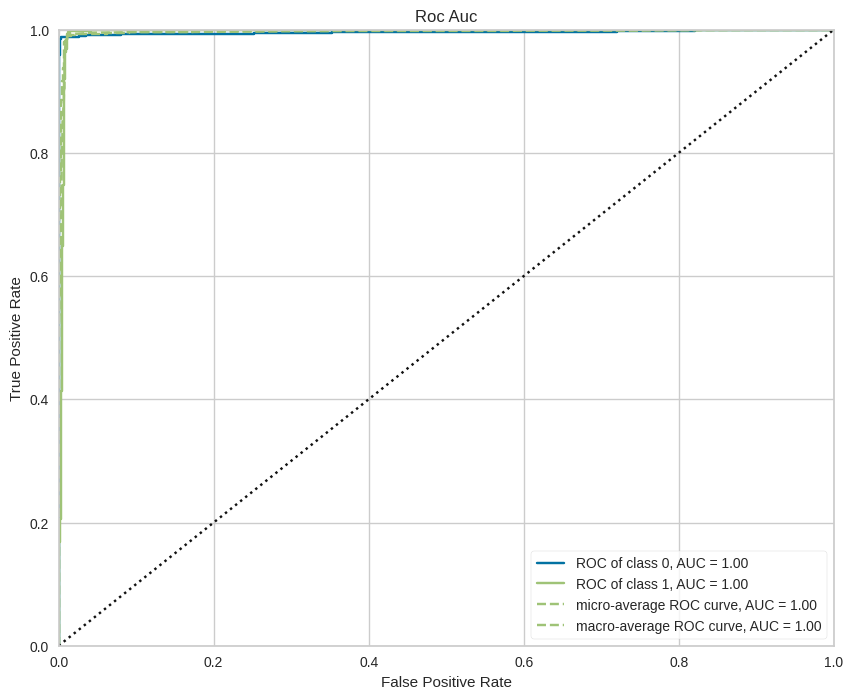

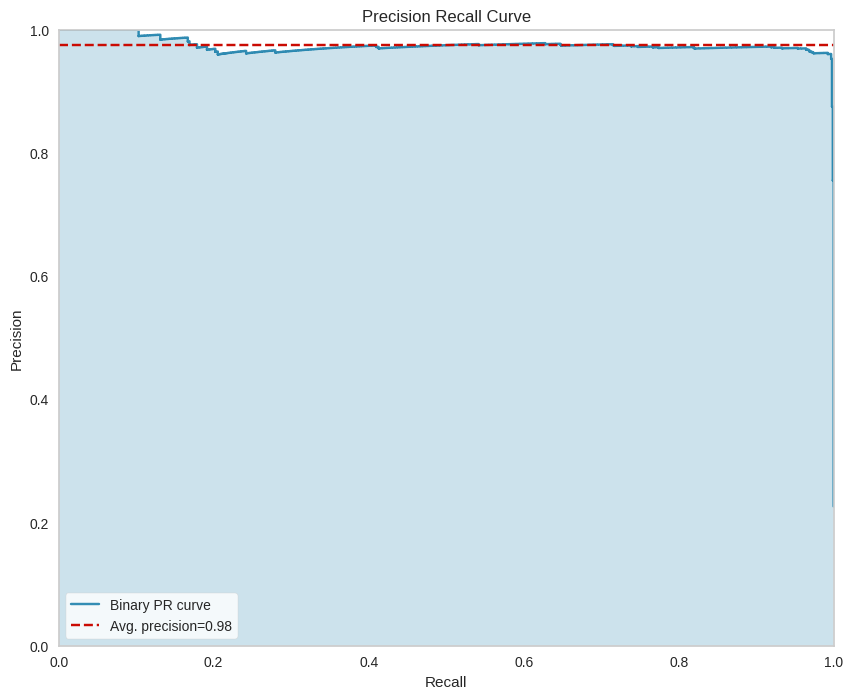

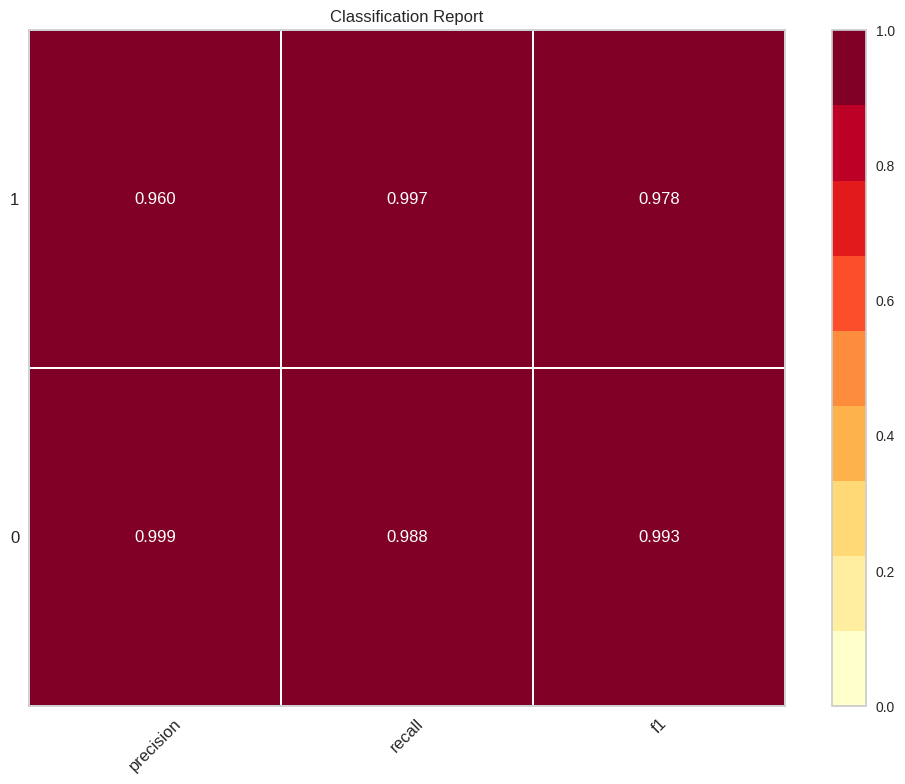

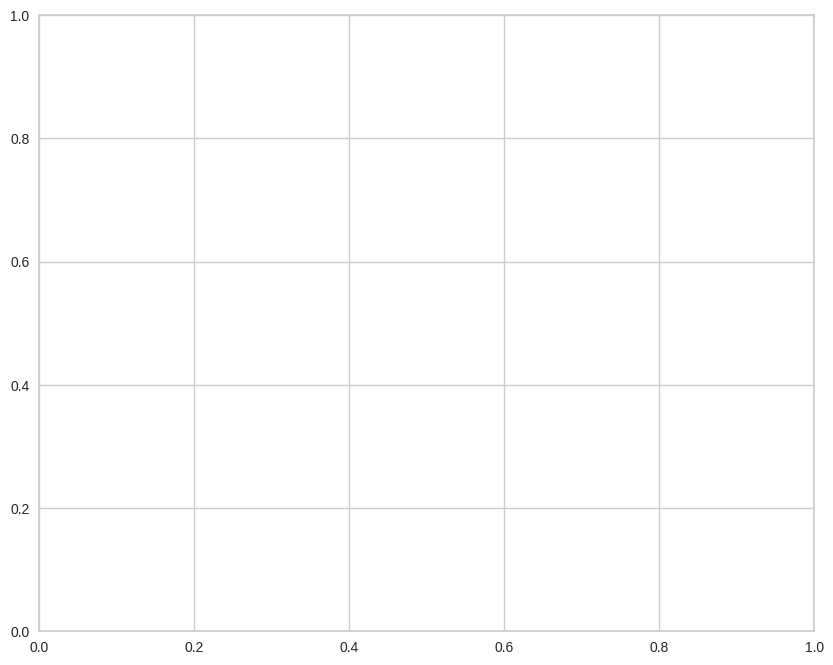

In [6]:
plotlist = YellowbrickConfigList(
    experiment=cls_experiment,
    plots=[
        "rank1d",
        "class_balance",
        "roc_auc",
        "precision_recall_curve",
        "classification_report",
        "learning_curve",
    ],
    plot_folder=(PLOT_DIR / "plotlist_demo").as_posix(),
)

_ = plotlist()

plotlist_files = sorted((PLOT_DIR / "plotlist_demo").glob("*.png"))
print("PlotList generated files:")
for p in plotlist_files:
    print(" -", p.as_posix())

## 6. Torch Support with a TinyNet on Small Synthetic Data

Most plots in this notebook use sklearn estimators. This section shows torch support using `PytorchModelConfig` and a minimal `TinyNet` classifier.

,plot_type,save_path
0,roc_auc,build/yellowbrick/plots/torch_roc_auc.png
1,precision_recall_curve,build/yellowbrick/plots/torch_precision_recall...
2,classification_report,build/yellowbrick/plots/torch_classification_r...


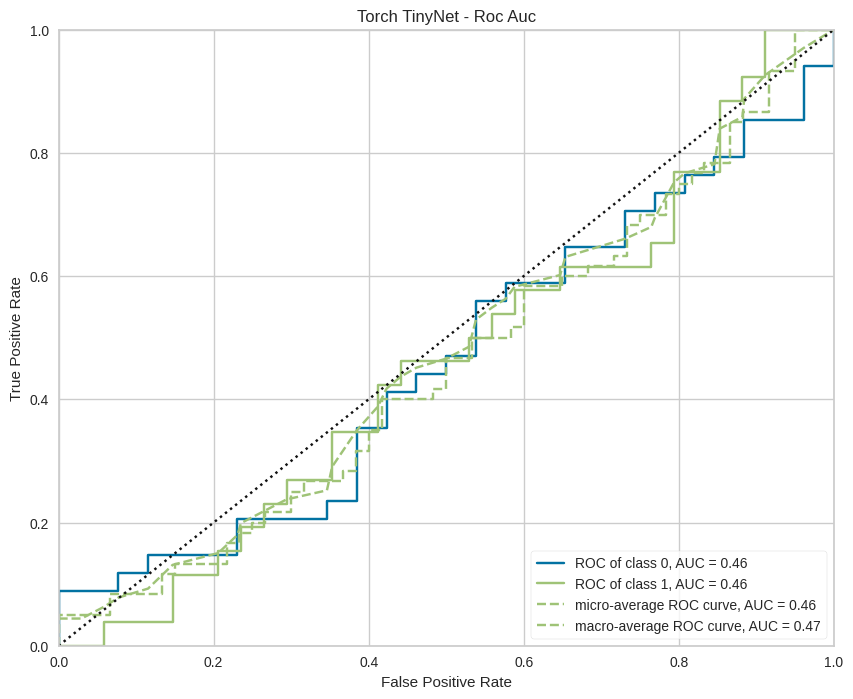

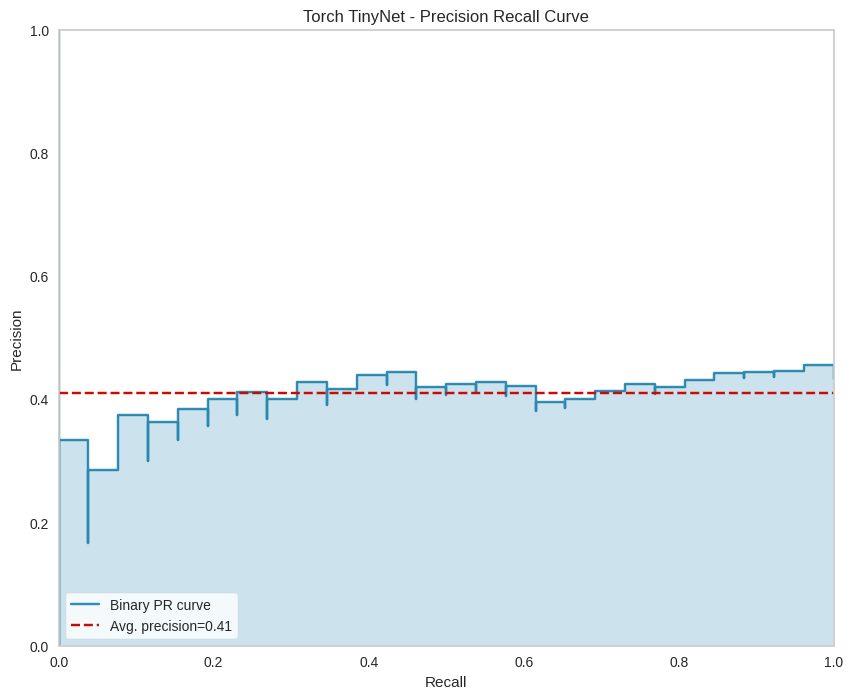

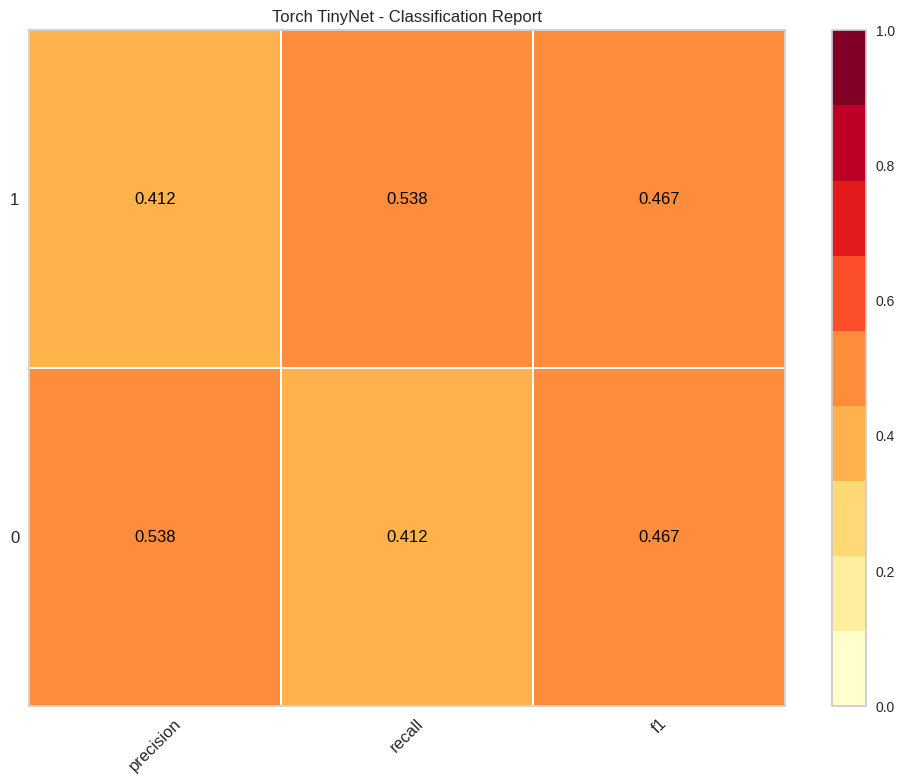

In [7]:
class TinyNet(nn.Module):
    def __init__(self, in_features: int, hidden: int = 16, out_features: int = 2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_features, hidden),
            nn.ReLU(),
            nn.Linear(hidden, out_features),
        )

    def forward(self, x):
        return self.net(x)


torch.manual_seed(42)
X_tiny = torch.randn(300, 6)
y_tiny = torch.randint(0, 2, (300,))

torch_data = PytorchDataConfig(
    dataset_name="torch.utils.data.TensorDataset",
    data_params={"_args_": [X_tiny, y_tiny], "batch_size": 32},
    train_size=240,
    test_size=60,
    random_state=42,
    classifier=True,
    stratify=True,
)

torch_model = PytorchModelConfig(
    model_type=TinyNet,
    model_params={"in_features": 6, "hidden": 16, "out_features": 2},
    classifier=True,
    criterion="CrossEntropyLoss",
    optimizer={"name": "torch.optim.Adam", "lr": 1e-2},
    fit_params={"nb_epochs": 5, "batch_size": 32},
    device="cpu",
)

torch_experiment = ExperimentConfig(
    data=torch_data,
    model=torch_model,
    classifier=True,
    files=FileConfig(),
)

_ = torch_experiment()

torch_plot_results = []
for plot_type in ["roc_auc", "precision_recall_curve", "classification_report"]:
    save_path = (PLOT_DIR / f"torch_{plot_type}.png").as_posix()
    cfg = YellowbrickPlotConfig(
        experiment=torch_experiment,
        plot_type=plot_type,
        classes="all",
        features="all",
        title=f"Torch TinyNet - {plot_type.replace('_', ' ').title()}",
        save_path=save_path,
    )
    cfg()
    torch_plot_results.append(
        {"plot_type": plot_type, "save_path": save_path, },
    )

pd.DataFrame(torch_plot_results)

## 7. One Plot Type per Cell

Run these cells top-to-bottom to generate one plot per cell. Explanations reference the scikit-yb API behavior for each visualizer.

[ok] rank1d: Univariate feature ranking for quick signal inspection.


,plot_type,status,save_path,error,explanation
0,rank1d,ok,build/yellowbrick/plots/all_types_rank1d.png,,Univariate feature ranking for quick signal in...


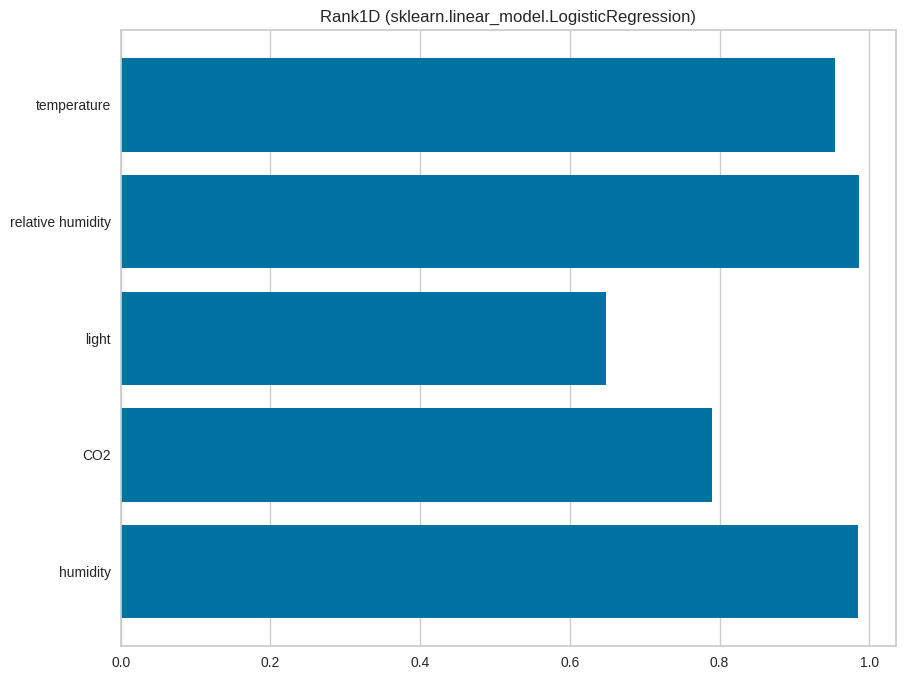

In [8]:
# rank1d: visual feature-by-feature ranking statistics to inspect univariate signal strength.
render_plot("rank1d", "Univariate feature ranking for quick signal inspection.")

[ok] rank2d: Pairwise feature relationship heatmap to spot redundancy.


,plot_type,status,save_path,error,explanation
0,rank2d,ok,build/yellowbrick/plots/all_types_rank2d.png,,Pairwise feature relationship heatmap to spot ...


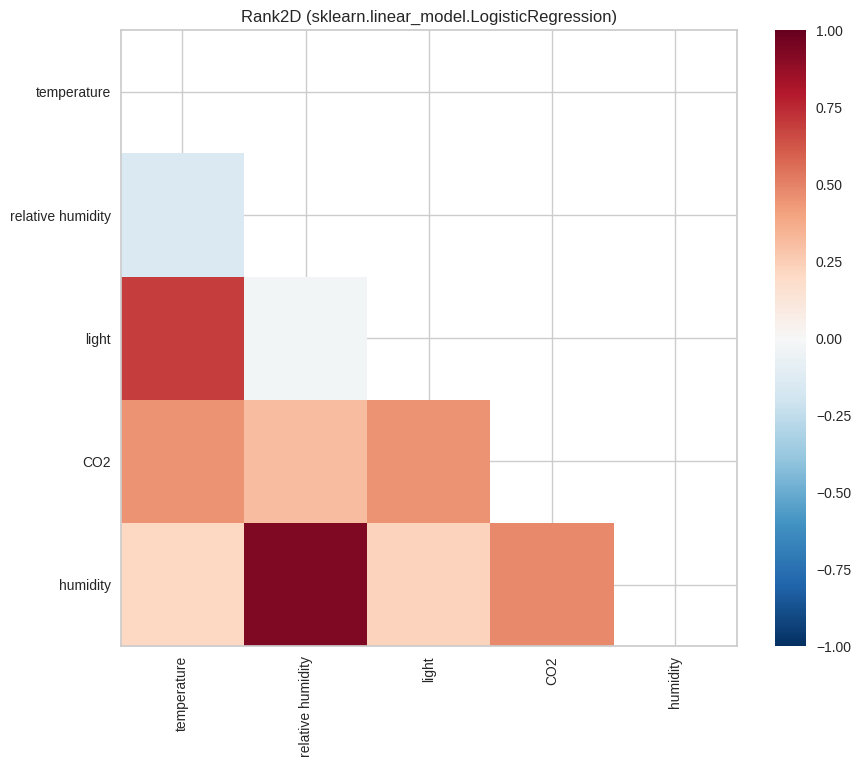

In [9]:
# rank2d: display pairwise correlation/covariance structure between features.
render_plot("rank2d", "Pairwise feature relationship heatmap to spot redundancy.")

[ok] radviz: Radial projection view of class separability.


,plot_type,status,save_path,error,explanation
0,radviz,ok,build/yellowbrick/plots/all_types_radviz.png,,Radial projection view of class separability.


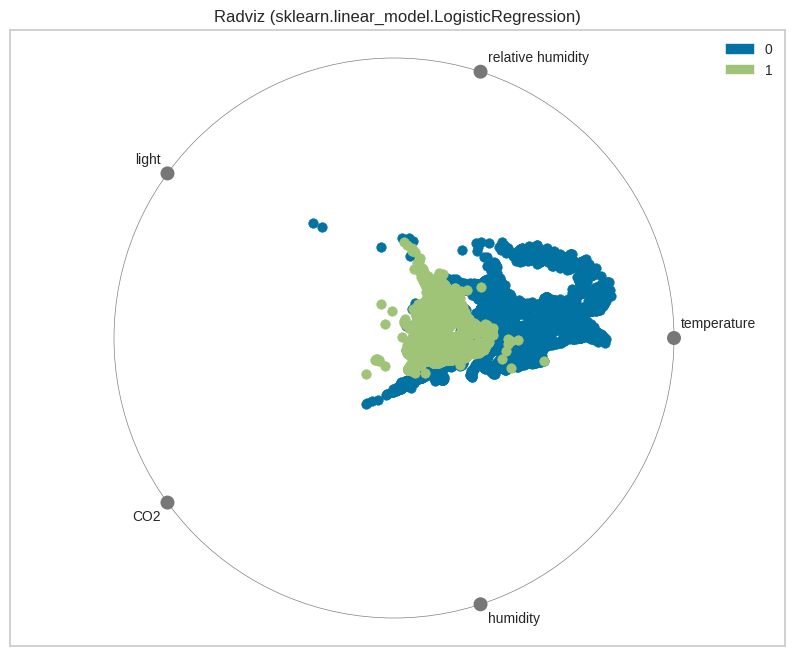

In [10]:
# radviz: project high-dimensional data radially to inspect class separation.
render_plot("radviz", "Radial projection view of class separability.")

[ok] pcoords: Parallel-coordinate trajectories across feature axes.


,plot_type,status,save_path,error,explanation
0,pcoords,ok,build/yellowbrick/plots/all_types_pcoords.png,,Parallel-coordinate trajectories across featur...


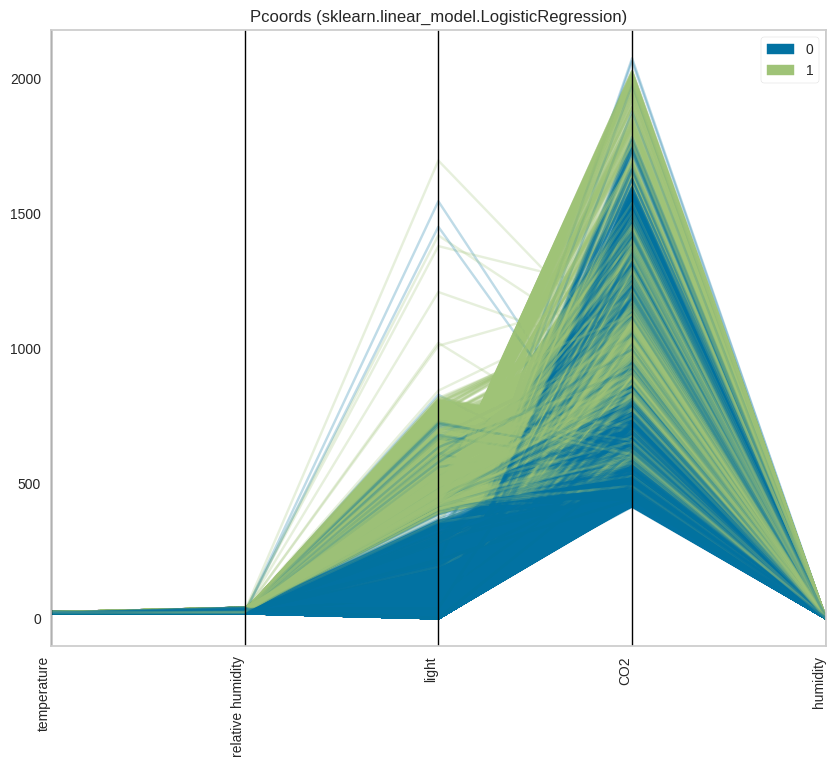

In [11]:
# pcoords: parallel coordinates show multivariate class patterns and overlap.
render_plot("pcoords", "Parallel-coordinate trajectories across feature axes.")

[ok] jointplot: Two-feature joint distribution and relationship view.


,plot_type,status,save_path,error,explanation
0,jointplot,ok,build/yellowbrick/plots/all_types_jointplot.png,,Two-feature joint distribution and relationshi...


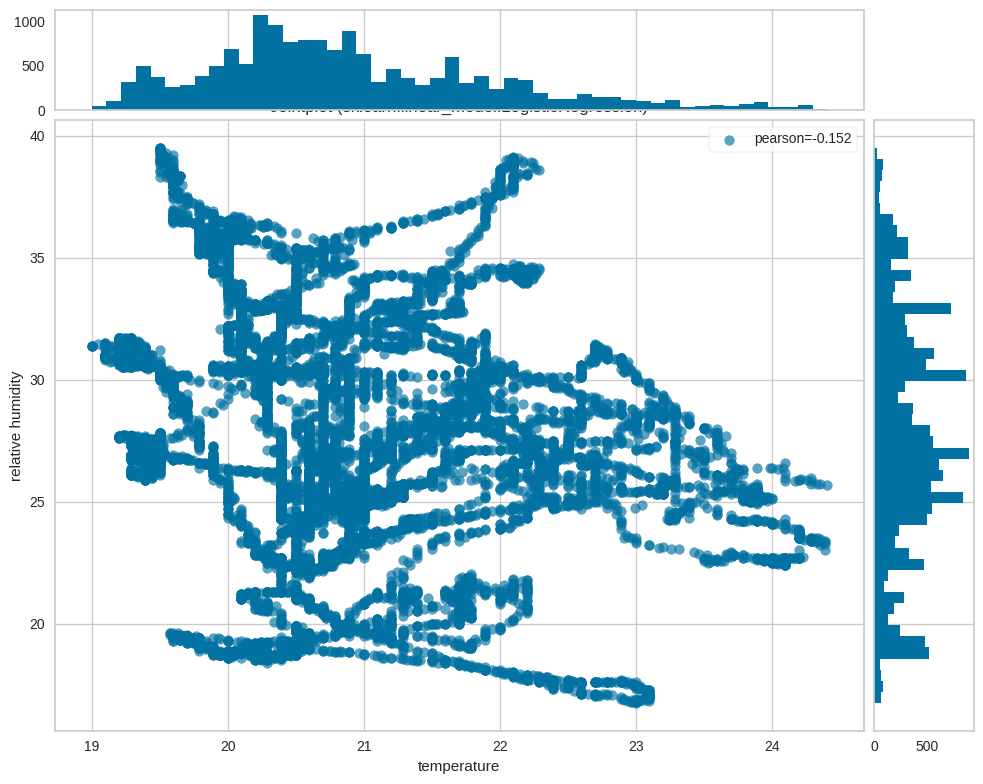

In [12]:
# jointplot: bivariate scatter/hist diagnostics on a selected feature pair.
render_plot("jointplot", "Two-feature joint distribution and relationship view.")

[ok] pca: Principal-component projection for low-dimensional structure.


,plot_type,status,save_path,error,explanation
0,pca,ok,build/yellowbrick/plots/all_types_pca.png,,Principal-component projection for low-dimensi...


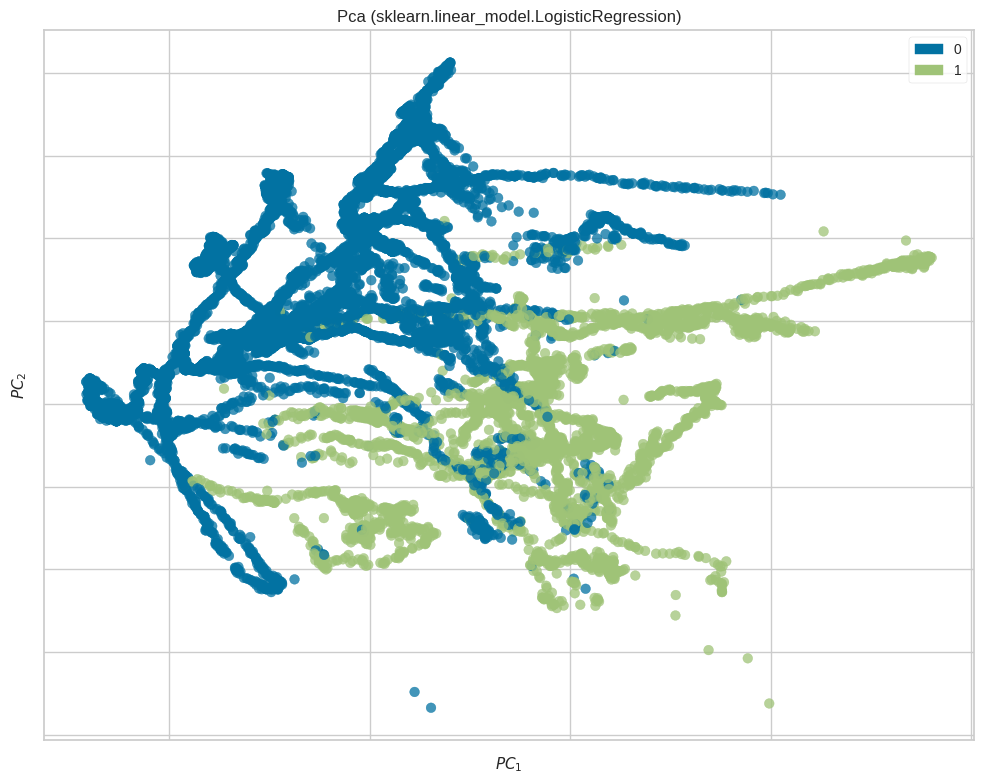

In [13]:
# pca: PCA projection helps inspect variance structure and class clustering in lower dimensions.
render_plot("pca", "Principal-component projection for low-dimensional structure.")

In [14]:
# manifold: non-linear manifold embedding highlights neighborhood/class topology.
# render_plot("manifold", "Nonlinear manifold embedding to inspect local geometry.")

[ok] class_balance: Class distribution overview for imbalance checks.


,plot_type,status,save_path,error,explanation
0,class_balance,ok,build/yellowbrick/plots/all_types_class_balanc...,,Class distribution overview for imbalance checks.


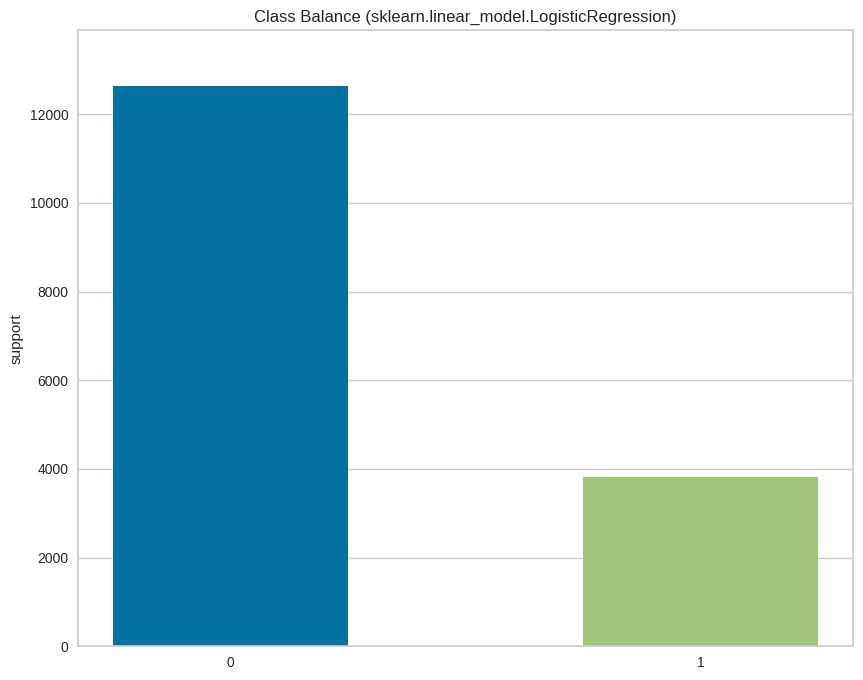

In [15]:
# class_balance: class-count bar chart for imbalance diagnostics.
render_plot("class_balance", "Class distribution overview for imbalance checks.")

[ok] balanced_binning_reference: Target-bin balance reference for response distribution.


,plot_type,status,save_path,error,explanation
0,balanced_binning_reference,ok,build/yellowbrick/plots/all_types_balanced_bin...,,Target-bin balance reference for response dist...


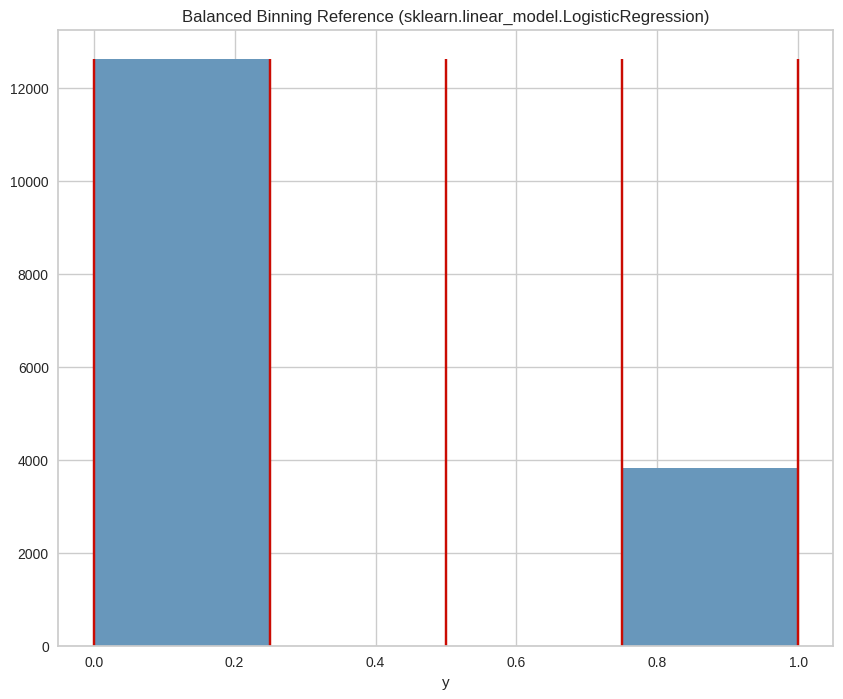

In [16]:
# balanced_binning_reference: target histogram with balanced binning reference lines.
render_plot("balanced_binning_reference", "Target-bin balance reference for response distribution.")

[ok] feature_correlation: Feature-target correlation strengths and direction.


,plot_type,status,save_path,error,explanation
0,feature_correlation,ok,build/yellowbrick/plots/all_types_feature_corr...,,Feature-target correlation strengths and direc...


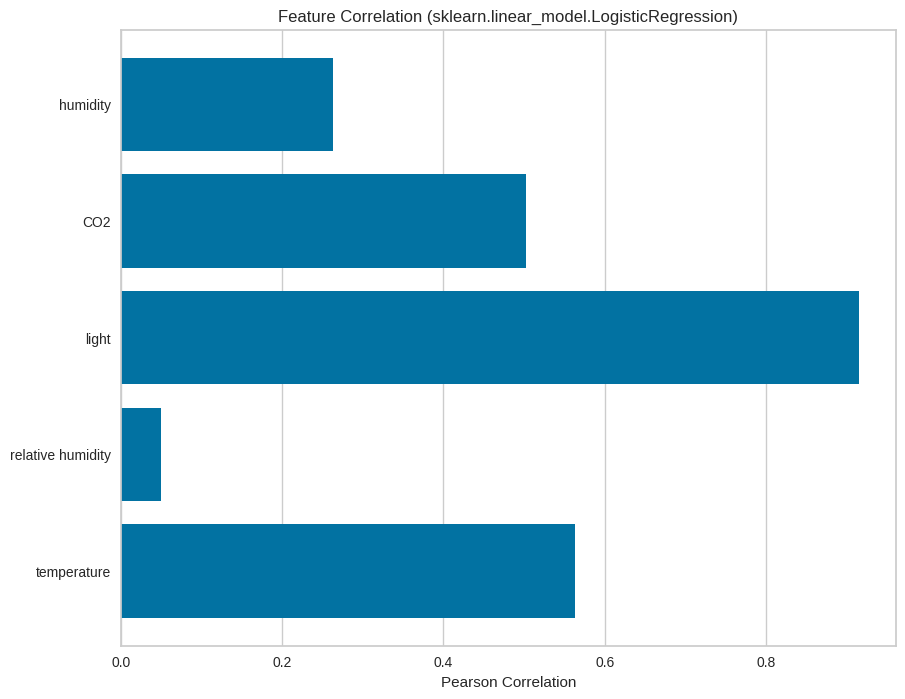

In [17]:
# feature_correlation: visualize how each feature associates with the target.
render_plot("feature_correlation", "Feature-target correlation strengths and direction.")

[ok] roc_auc: ROC curves summarize TPR/FPR tradeoff across thresholds.


,plot_type,status,save_path,error,explanation
0,roc_auc,ok,build/yellowbrick/plots/all_types_roc_auc.png,,ROC curves summarize TPR/FPR tradeoff across t...


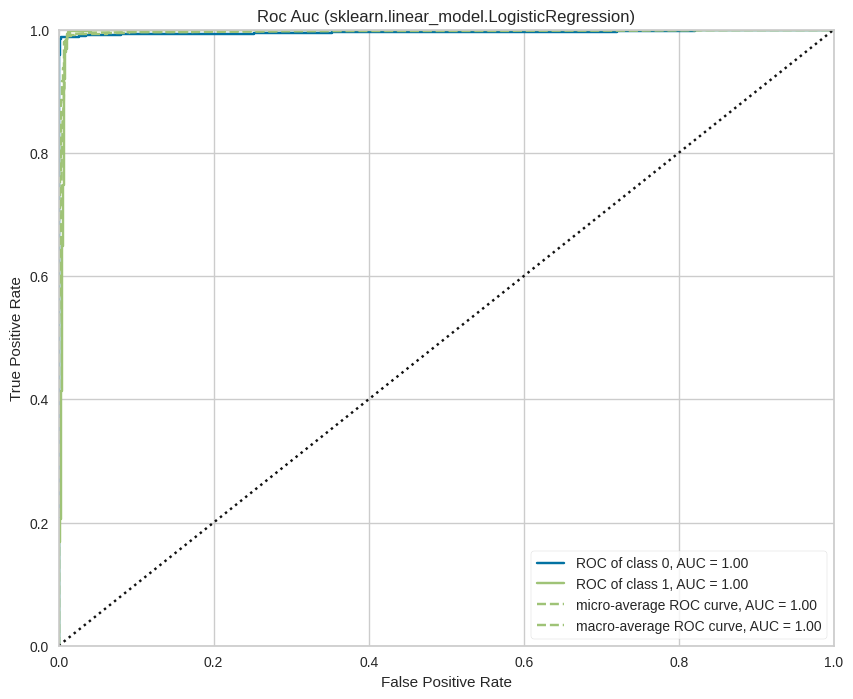

In [18]:
# roc_auc: threshold-swept ROC curves and area under curve for classifier discrimination.
render_plot("roc_auc", "ROC curves summarize TPR/FPR tradeoff across thresholds.")

[ok] precision_recall_curve: Precision-recall curves for imbalanced positive-class evaluation.


,plot_type,status,save_path,error,explanation
0,precision_recall_curve,ok,build/yellowbrick/plots/all_types_precision_re...,,Precision-recall curves for imbalanced positiv...


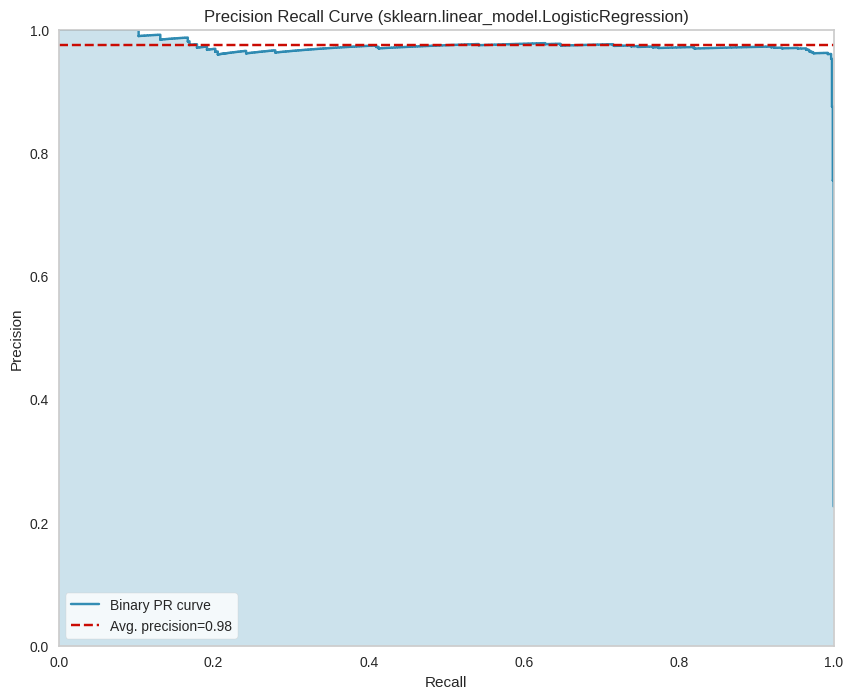

In [19]:
# precision_recall_curve: precision-recall tradeoff focused on positive-class retrieval quality.
render_plot("precision_recall_curve", "Precision-recall curves for imbalanced positive-class evaluation.")

[ok] classification_report: Per-class precision, recall, and F1 diagnostics.


,plot_type,status,save_path,error,explanation
0,classification_report,ok,build/yellowbrick/plots/all_types_classificati...,,"Per-class precision, recall, and F1 diagnostics."


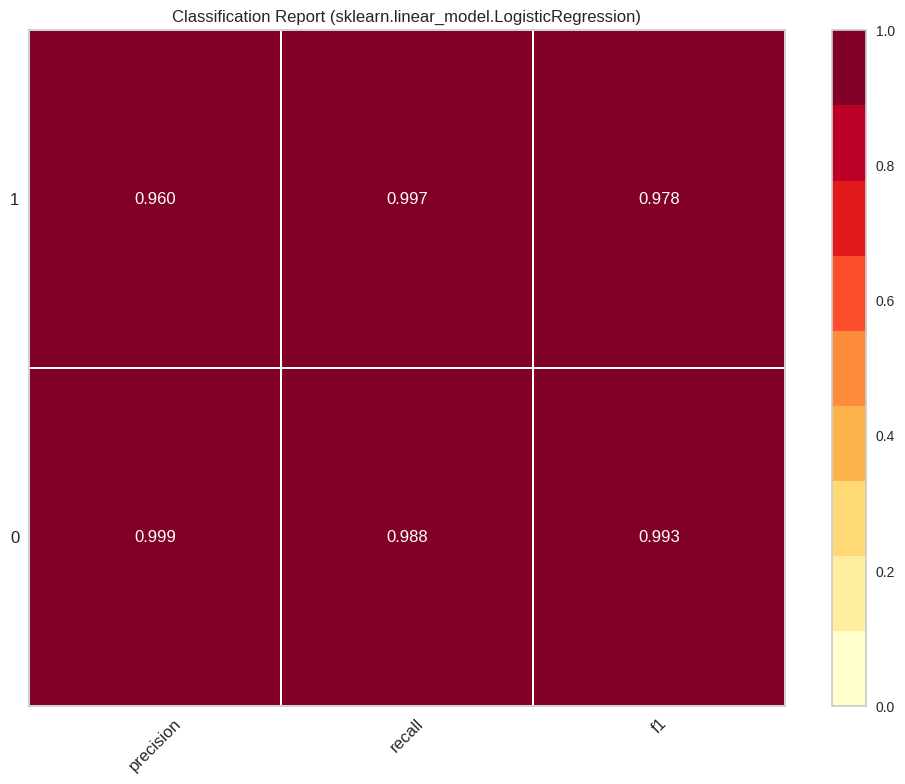

In [20]:
# classification_report: per-class precision/recall/f1 heatmap-style report.
render_plot("classification_report", "Per-class precision, recall, and F1 diagnostics.")

[ok] class_prediction_error: Class-wise misclassification structure and confusion patterns.


,plot_type,status,save_path,error,explanation
0,class_prediction_error,ok,build/yellowbrick/plots/all_types_class_predic...,,Class-wise misclassification structure and con...


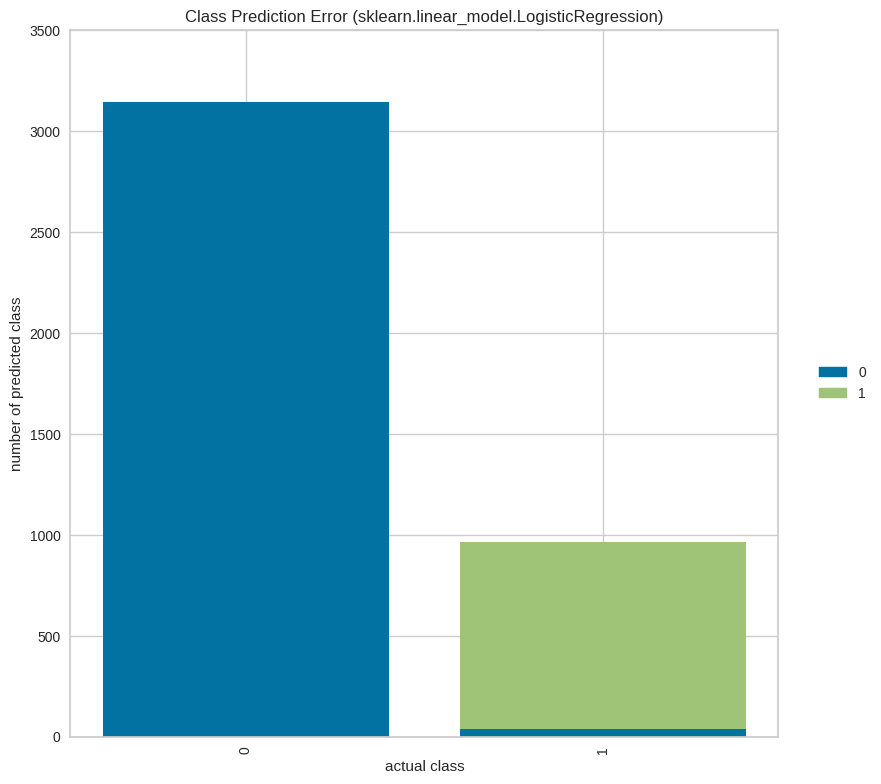

In [21]:
# class_prediction_error: confusion-style matrix of true vs predicted classes.
render_plot("class_prediction_error", "Class-wise misclassification structure and confusion patterns.")

[ok] discrimination_threshold: Binary threshold tuning with metric trajectories.


,plot_type,status,save_path,error,explanation
0,discrimination_threshold,ok,build/yellowbrick/plots/all_types_discriminati...,,Binary threshold tuning with metric trajectories.


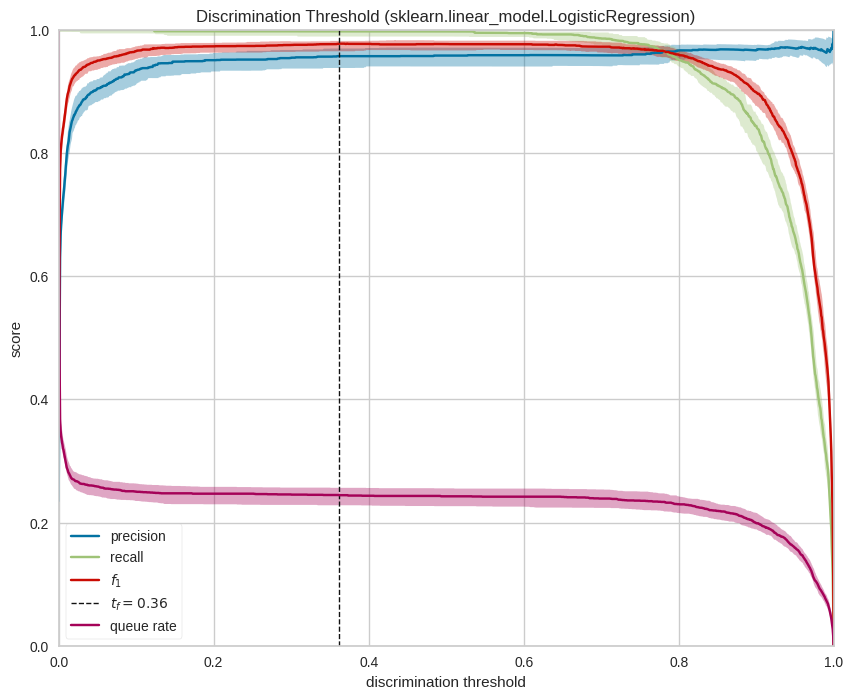

In [22]:
# discrimination_threshold: metric-vs-threshold curves to tune binary cutoff.
render_plot("discrimination_threshold", "Binary threshold tuning with metric trajectories.")

[ok] prediction_error: Predicted-versus-actual scatter for regression fidelity.


,plot_type,status,save_path,error,explanation
0,prediction_error,ok,build/yellowbrick/plots/all_types_prediction_e...,,Predicted-versus-actual scatter for regression...


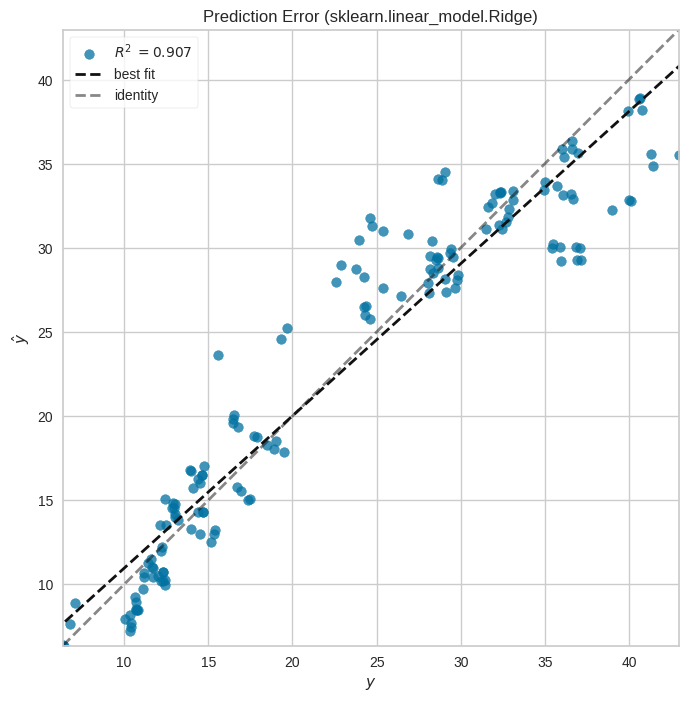

In [23]:
# prediction_error: compare predicted vs true values in regression.
render_plot("prediction_error", "Predicted-versus-actual scatter for regression fidelity.")

[ok] residuals_plot: Residual diagnostics to detect bias and heteroscedasticity.


,plot_type,status,save_path,error,explanation
0,residuals_plot,ok,build/yellowbrick/plots/all_types_residuals_pl...,,Residual diagnostics to detect bias and hetero...


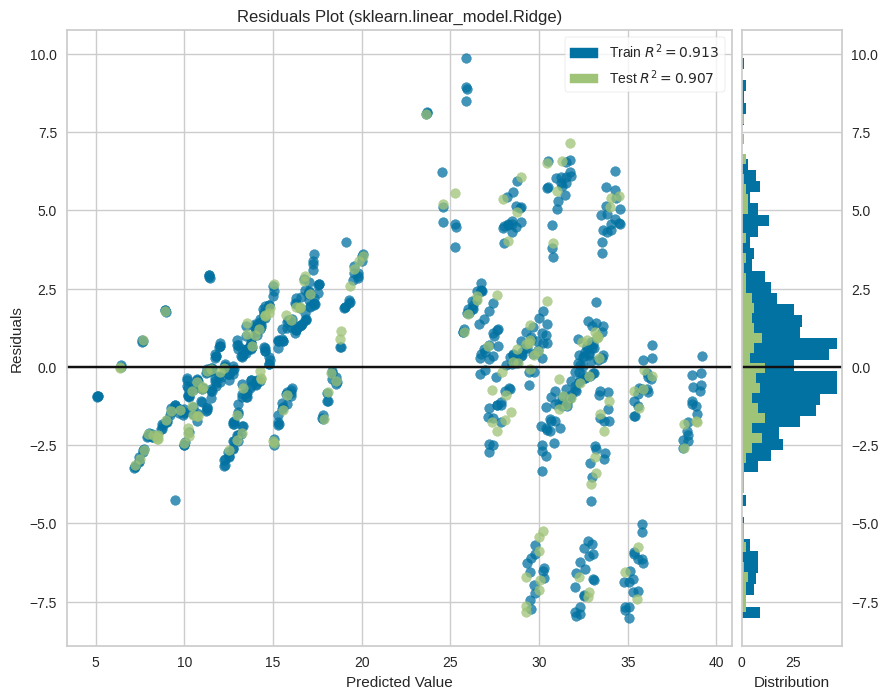

In [24]:
# residuals_plot: inspect residual spread and bias patterns.
render_plot("residuals_plot", "Residual diagnostics to detect bias and heteroscedasticity.")

[failed] alpha_selection: Regularization sweep to choose alpha on ridge-like models.
error: list indices must be integers or slices, not tuple


,plot_type,status,save_path,error,explanation
0,alpha_selection,failed,build/yellowbrick/plots/all_types_alpha_select...,"list indices must be integers or slices, not t...",Regularization sweep to choose alpha on ridge-...


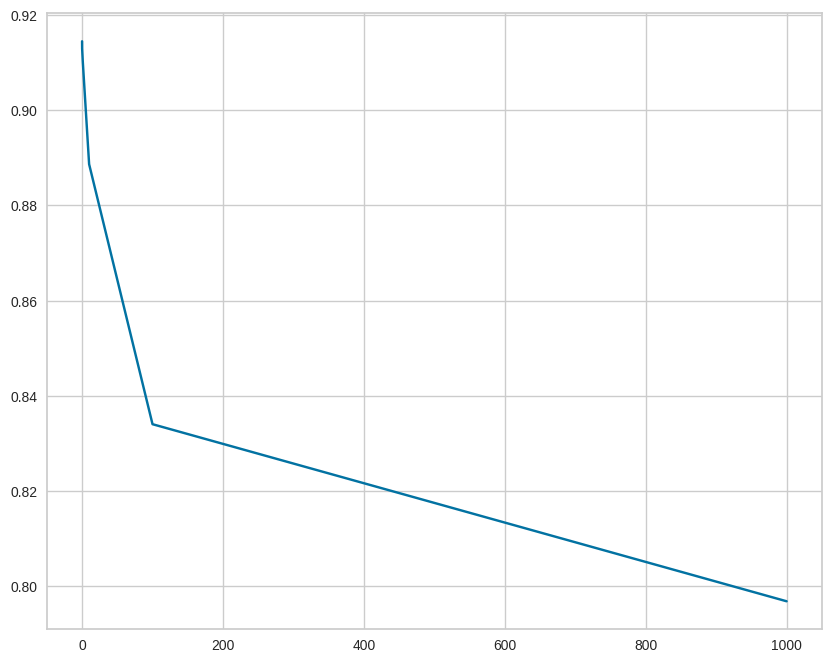

In [25]:
# alpha_selection: evaluate regularization strength sweep for alpha-based regressors.
render_plot("alpha_selection", "Regularization sweep to choose alpha on ridge-like models.")

[ok] k_elbow: Inertia-by-k curve for selecting cluster count.


,plot_type,status,save_path,error,explanation
0,k_elbow,ok,build/yellowbrick/plots/all_types_k_elbow.png,,Inertia-by-k curve for selecting cluster count.


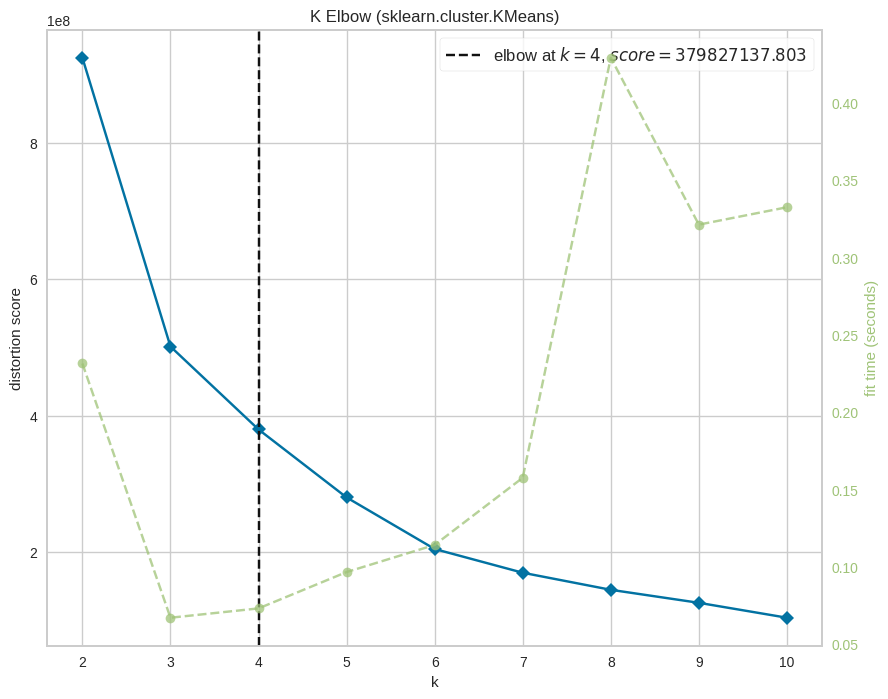

In [26]:
# k_elbow: identify an elbow in cluster-inertia vs k.
render_plot("k_elbow", "Inertia-by-k curve for selecting cluster count.")

[ok] silhouette: Cluster quality via silhouette score distribution.


,plot_type,status,save_path,error,explanation
0,silhouette,ok,build/yellowbrick/plots/all_types_silhouette.png,,Cluster quality via silhouette score distribut...


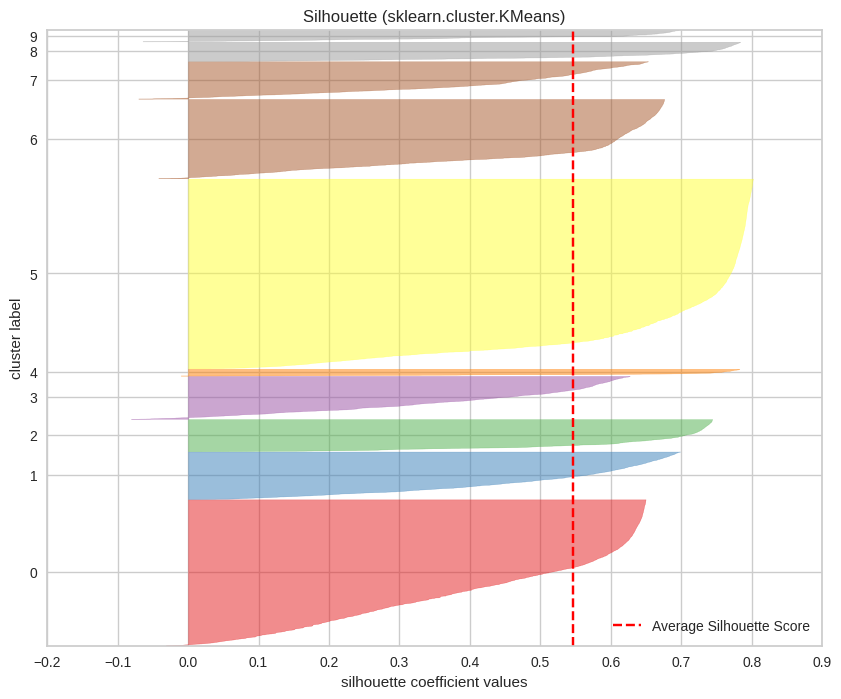

In [27]:
# silhouette: assess cluster cohesion/separation through silhouette coefficients.
render_plot("silhouette", "Cluster quality via silhouette score distribution.")

[ok] intercluster_distance: Centroid-distance map of cluster separation.


,plot_type,status,save_path,error,explanation
0,intercluster_distance,ok,build/yellowbrick/plots/all_types_intercluster...,,Centroid-distance map of cluster separation.


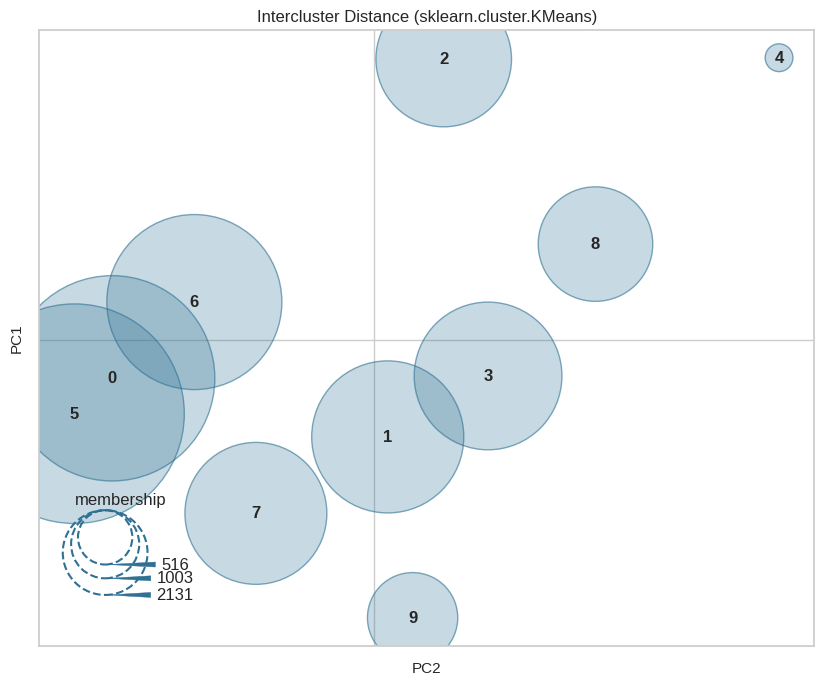

In [28]:
# intercluster_distance: project centroid distances to inspect cluster separability.
render_plot("intercluster_distance", "Centroid-distance map of cluster separation.")

[ok] validation_curve: Hyperparameter sensitivity curve with cross-validation.


,plot_type,status,save_path,error,explanation
0,validation_curve,ok,build/yellowbrick/plots/all_types_validation_c...,,Hyperparameter sensitivity curve with cross-va...


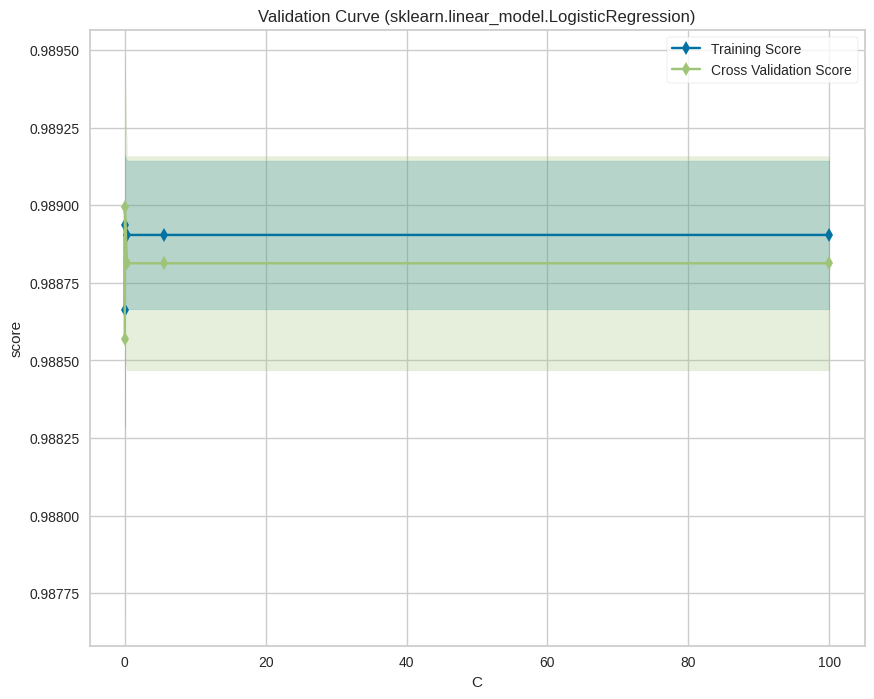

In [29]:
# validation_curve: score vs hyperparameter value under cross-validation.
render_plot("validation_curve", "Hyperparameter sensitivity curve with cross-validation.")

[ok] learning_curve: Data-size scaling curve for bias-variance diagnostics.


,plot_type,status,save_path,error,explanation
0,learning_curve,ok,build/yellowbrick/plots/all_types_learning_cur...,,Data-size scaling curve for bias-variance diag...


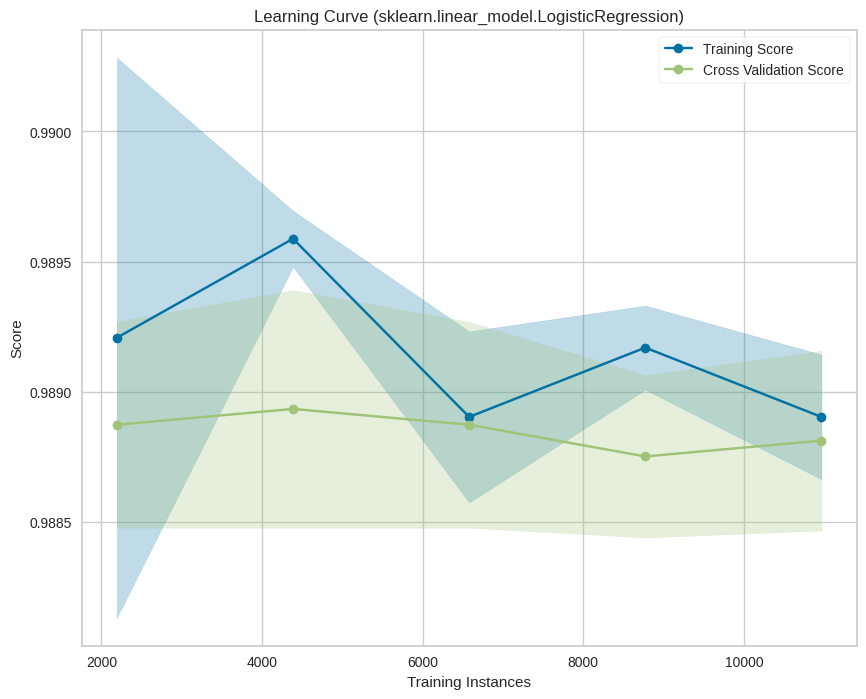

In [30]:
# learning_curve: training/validation performance as train size increases.
render_plot("learning_curve", "Data-size scaling curve for bias-variance diagnostics.")

[ok] cv_scores: Cross-validation fold score variability and stability.


,plot_type,status,save_path,error,explanation
0,cv_scores,ok,build/yellowbrick/plots/all_types_cv_scores.png,,Cross-validation fold score variability and st...


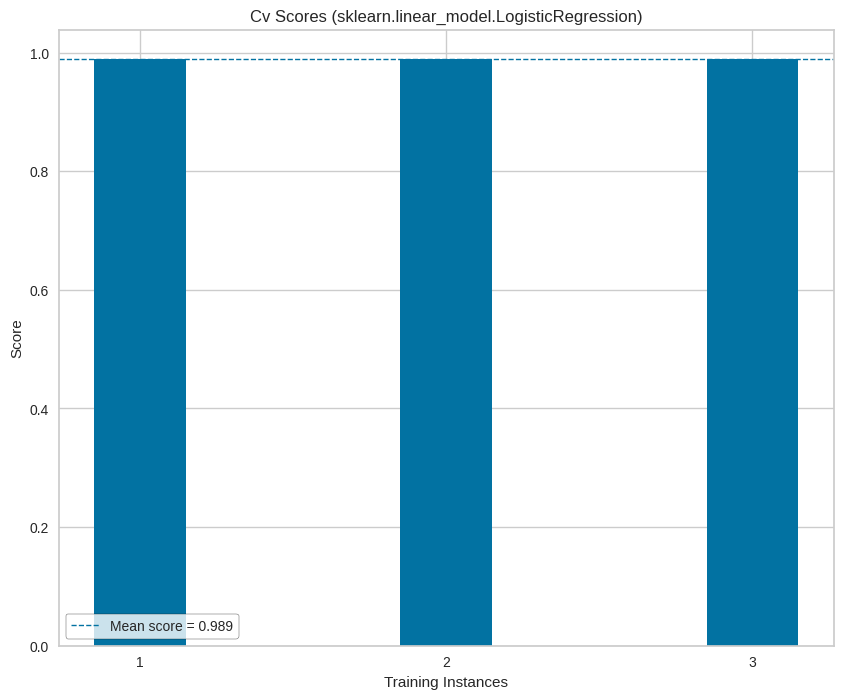

In [31]:
# cv_scores: fold-wise cross-validation score distribution.
render_plot("cv_scores", "Cross-validation fold score variability and stability.")

[ok] feature_importances: Model feature-importance ranking for interpretation.


,plot_type,status,save_path,error,explanation
0,feature_importances,ok,build/yellowbrick/plots/all_types_feature_impo...,,Model feature-importance ranking for interpret...


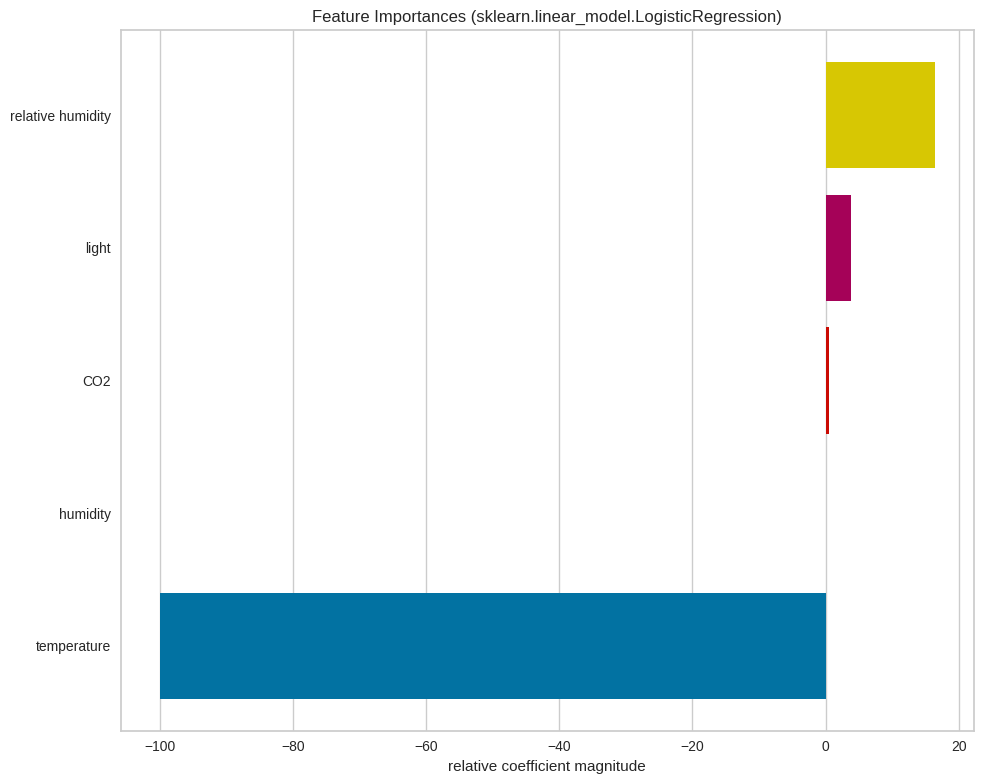

In [32]:
# feature_importances: model-derived feature importance ranking.
render_plot("feature_importances", "Model feature-importance ranking for interpretation.")

[ok] rfecv: Cross-validated recursive feature elimination path.


,plot_type,status,save_path,error,explanation
0,rfecv,ok,build/yellowbrick/plots/all_types_rfecv.png,,Cross-validated recursive feature elimination ...


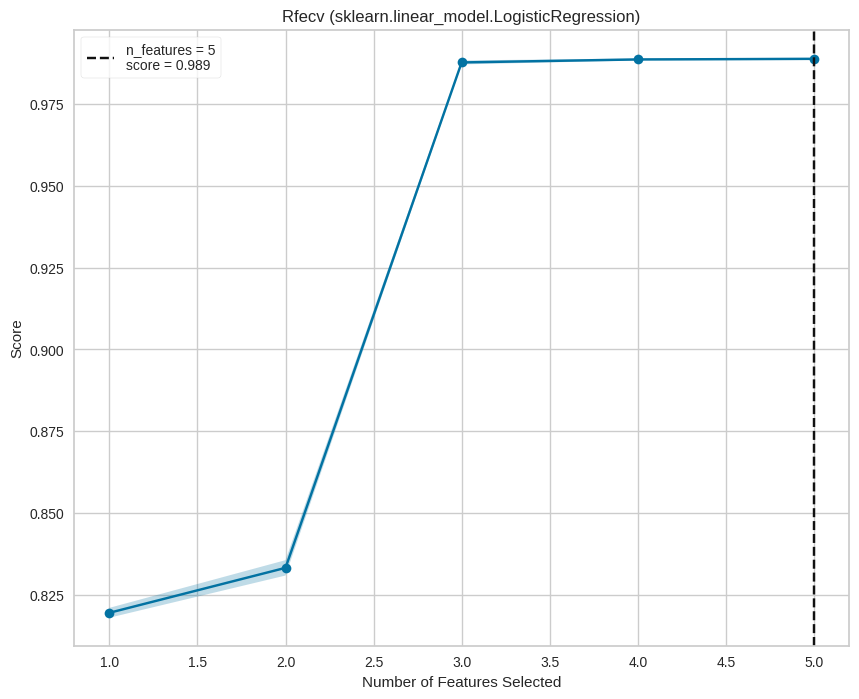

In [33]:
# rfecv: recursive feature elimination with cross-validation to pick feature subset size.
render_plot("rfecv", "Cross-validated recursive feature elimination path.")

[ok] dropping_curve: Performance degradation profile under feature dropping.


,plot_type,status,save_path,error,explanation
0,dropping_curve,ok,build/yellowbrick/plots/all_types_dropping_cur...,,Performance degradation profile under feature ...


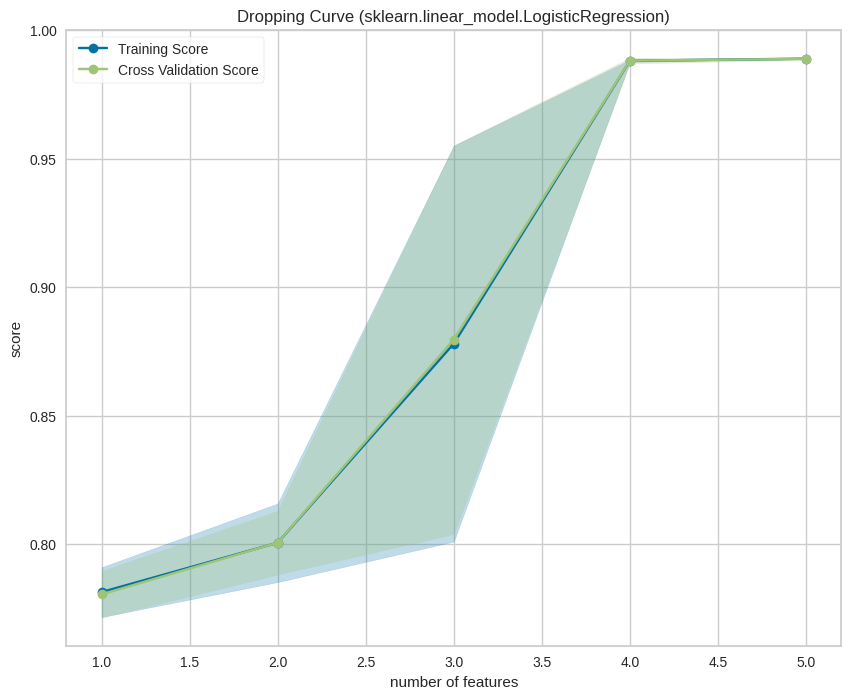

In [34]:
# dropping_curve: score change as features are removed from the model.
render_plot("dropping_curve", "Performance degradation profile under feature dropping.")